In [1]:
import os
import json
import sys
from tempfile import mkdtemp

from imblearn.over_sampling import ADASYN, SMOTE

# make lib/ importable from the notebooks/ directory
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, Normalizer
from lib import label_images

DATA_DIR = "../data"
LABELS_CSV = DATA_DIR + "/labels.csv"
CACHE_FILE = DATA_DIR + "/split_cache.npz"
IMG_SIZE = (64, 64)
CROP_FRAC = 0.80  # keep central 80% of each axis → drops ~10% border on each side

if not os.path.exists(LABELS_CSV):
    label_images.main()

df = pd.read_csv(LABELS_CSV)


In [2]:

def load_dicom(path, size=IMG_SIZE, crop_frac=CROP_FRAC):
    ds = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    # center crop — removes border text/watermarks
    h, w = arr.shape
    ch, cw = int(h * crop_frac), int(w * crop_frac)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    arr = arr[y0:y0+ch, x0:x0+cw]
    # resize and flatten
    img = Image.fromarray((arr * 255).astype(np.uint8)).resize(size)
    return np.array(img).flatten()

# NOTE: delete data/split_cache.npz whenever CROP_FRAC changes — the cache
# stores flattened pixels and will be stale if the crop parameters differ.
if os.path.exists(CACHE_FILE):
    print(f"Loading split from cache: {CACHE_FILE}")
    print(f"  (cached with CROP_FRAC={CROP_FRAC} — delete cache if this changed)")
    cache = np.load(CACHE_FILE)
    X_train, X_test, y_train, y_test = cache["X_train"], cache["X_test"], cache["y_train"], cache["y_test"]
else:
    df = pd.read_csv(LABELS_CSV)
    print(f"Total images: {len(df)}  |  sick: {(df.label==1).sum()}  |  not_sick: {(df.label==0).sum()}")
    print(f"CROP_FRAC={CROP_FRAC}  IMG_SIZE={IMG_SIZE}")

    print("Loading images...")
    X = np.array([load_dicom(p) for p in df["dicom_path"]])
    y = df["label"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    np.savez_compressed(CACHE_FILE, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
    print(f"Split cached to: {CACHE_FILE}")

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


Loading split from cache: ../data/split_cache.npz
  (cached with CROP_FRAC=0.8 — delete cache if this changed)
X_train: (23932, 4096)  |  X_test: (5984, 4096)


In [3]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import Normalizer
from imblearn.over_sampling import SMOTE

memory = mkdtemp()
pipeline = Pipeline([
    ('normalizer', Normalizer()),
    ('pca', PCA(n_components=0.95)),
    ('smt', SMOTE()),
    ('knn', KNeighborsClassifier(n_jobs=-1)),
], memory=memory)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.61      0.72      4134
           1       0.48      0.78      0.59      1850

    accuracy                           0.67      5984
   macro avg       0.67      0.70      0.65      5984
weighted avg       0.74      0.67      0.68      5984



In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Reconstruct full dataset from cached split
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    "precision_sick": "precision",
    "recall_sick":    "recall",
    "f1_sick":        "f1",
    "accuracy":       "accuracy",
}

print("Running 3-fold stratified CV on full dataset (this may take several minutes)...")
cv_results = cross_validate(
    pipeline,
    X_all, y_all,
    cv=cv,
    scoring=scoring,
    n_jobs=1,  # KNN already uses n_jobs=-1 internally
    return_train_score=False,
)

results_df = pd.DataFrame({
    k.replace("test_", ""): v for k, v in cv_results.items()
    if k.startswith("test_")
})
results_df.index = [f"fold_{i+1}" for i in range(3)]
results_df.loc["mean"] = results_df.mean()
results_df.loc["std"]  = results_df.std()
print(results_df.round(3).to_string())

Running 3-fold stratified CV on full dataset (this may take several minutes)...
        precision_sick  recall_sick  f1_sick  accuracy
fold_1           0.483        0.789    0.599     0.673
fold_2           0.482        0.774    0.594     0.673
fold_3           0.484        0.768    0.594     0.675
mean             0.483        0.777    0.596     0.674
std              0.001        0.009    0.002     0.001


Computing OOF probabilities for CM and ROC (this may take several minutes)...


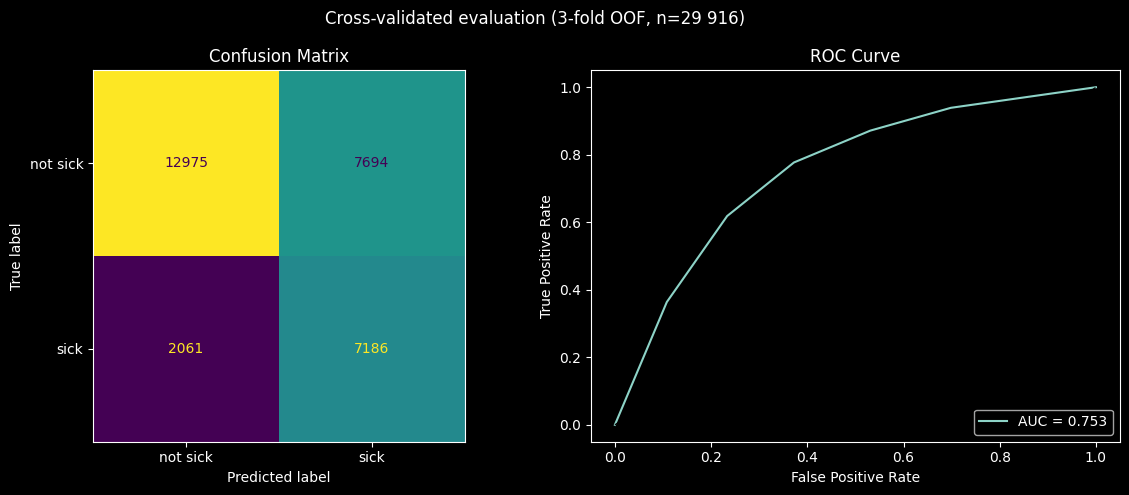

ROC AUC (OOF): 0.753


In [5]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("Computing OOF probabilities for CM and ROC (this may take several minutes)...")
y_proba_cv = cross_val_predict(
    pipeline, X_all, y_all, cv=cv, method="predict_proba", n_jobs=1
)
y_pred_cv = y_proba_cv.argmax(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Cross-validated evaluation (3-fold OOF, n=29 916)")

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_all, y_pred_cv),
    display_labels=["not sick", "sick"],
).plot(ax=ax1, colorbar=False)
ax1.set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_all, y_proba_cv[:, 1])
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()
print(f"ROC AUC (OOF): {roc_auc:.3f}")

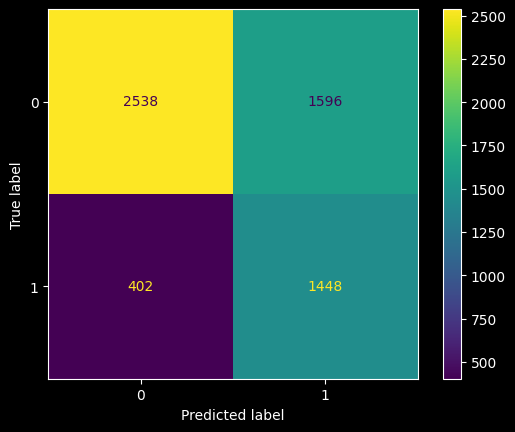

In [6]:
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()